# 051 门控记忆与编码解码
从同一两样本GRU数值链到完整六模型反序列实验。Run All会重新训练1800步，不只加载旧曲线。需要Noto Sans CJK字体，见README。作者计算复核不替代独立QA。

In [1]:
from pathlib import Path
import sys,os,json,gzip,io,tempfile,unittest
root=Path.cwd()
if (root/'units/051').is_dir():root=root/'units/051'
if not (root/'experiment.py').is_file():raise RuntimeError('从课程根或units/051启动')
sys.path.insert(0,str(root))
import numpy as np,torch,matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from IPython.display import Image,display
from experiment import run,batch,greedy,initialize
from hand_calculation import ledger
from audit_records import audit
import test_experiment
torch.set_num_threads(1)
font=os.environ.get('DL_CJK_FONT','/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')
if not Path(font).is_file():raise RuntimeError('完整Notebook需要Noto Sans CJK，见README')
plt.rcParams.update({'font.family':FontProperties(fname=font).get_name(),'font.size':11,'axes.unicode_minus':False})
def require(ok,message):
    if not ok:raise RuntimeError(message)
def show(fig):
    buf=io.BytesIO();fig.savefig(buf,format='png',dpi=150,bbox_inches='tight');display(Image(data=buf.getvalue()));plt.close(fig)
print({'python':sys.version.split()[0],'torch':torch.__version__,'numpy':np.__version__,'device':'CPU float64'})

{'python': '3.12.14', 'torch': '2.7.1+cpu', 'numpy': '2.3.5', 'device': 'CPU float64'}


## 1 同一实例的三次前向
重新计算每个时间步的门与14参数贡献。样本2变差也保留；不要用新参数的梯度更新旧参数的另一部分。

step 0 theta [0.4, -0.3, 0.5, 0.2, 0.1, -0.4, 0.1, -0.2, 0.05, -0.05, 0.1, 0.02, 1.2, -0.1] loss 0.03903462140418047
sample 0 prediction -0.1387478725794933 steps [{'time': 1, 'x': 1.0, 'h_prev': 0.0, 'r': 0.610639233949222, 'z': 0.401312339887548, 'n': 0.509617382192567, 'hidden_affine_n': 0.02, 'h': 0.3051016380975011}, {'time': 2, 'x': -1.0, 'h_prev': 0.3051016380975011, 'r': 0.4282536784925246, 'z': 0.5573737199038152, 'n': -0.4571475709653426, 'hidden_affine_n': -0.10204065523900045, 'h': -0.03228989381624442}] gradient [-0.0019983497572247104, 0.05102422911185262, 0.02482028507100368, 0.0005424661008485477, -0.011661462828475742, -0.00929813796916441, 0.0015576200122669383, -0.025418905714903677, -0.11750443567515126, 0.0015576200122669383, -0.025418905714903677, -0.058773831962056586, 0.005469066418035268, -0.16937393628974667]
sample 1 prediction 0.10344130465465762 steps [{'time': 1, 'x': 0.5, 'h_prev': 0.0, 'r': 0.5621765008857981, 'z': 0.4378234991142019, 'n': 0.301567960023

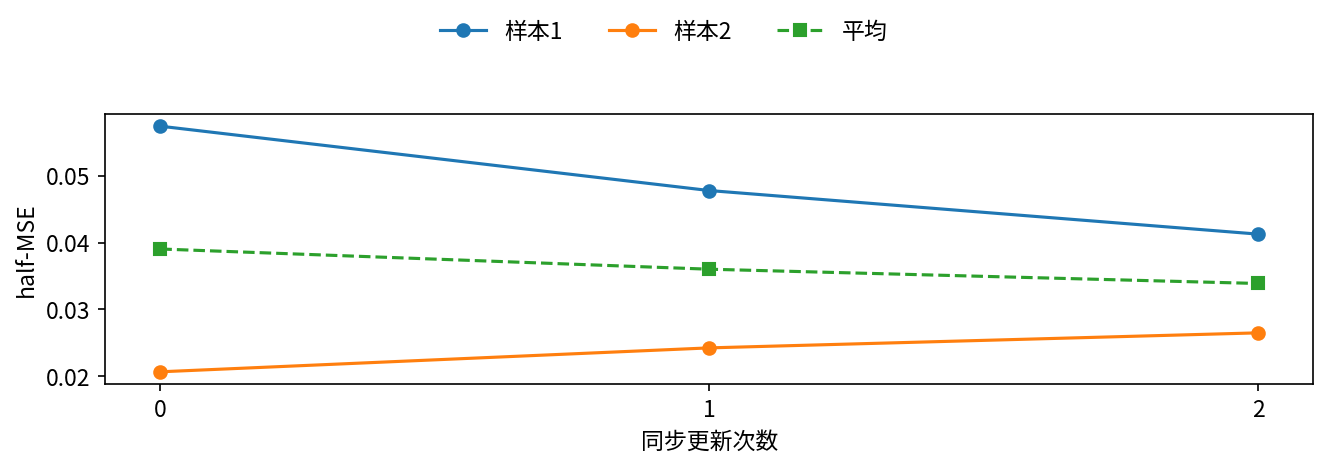

In [2]:
complete_hand=ledger();hand=complete_hand['states'];require(complete_hand==json.loads((root/'outputs/hand_ledger.json').read_text()),'手算账本不一致')
for state in hand:
    print('step',state['step'],'theta',state['theta'],'loss',state['loss'])
    for i,s in enumerate(state['samples']):print('sample',i,'prediction',s['prediction'],'steps',s['steps'],'gradient',s['gradient_contribution'])
fig,ax=plt.subplots(figsize=(9,3.2))
for i in range(2):ax.plot(range(3),[s['samples'][i]['individual_half_mse'] for s in hand],'o-',label=f'样本{i+1}')
ax.plot(range(3),[s['loss'] for s in hand],'s--',label='平均');ax.set(xlabel='同步更新次数',ylabel='half-MSE',xticks=[0,1,2]);fig.legend(*ax.get_legend_handles_labels(),loc='upper center',ncol=3,frameon=False);fig.tight_layout(rect=[0,0,1,.82]);show(fig)

## 2 局部导数与完整参照
旧状态上游是保留直路与所有门/候选路径之和。测试还包括非零旧h的官方cell对照、全部小模型自由参数FD与完整终点官方cell生成。

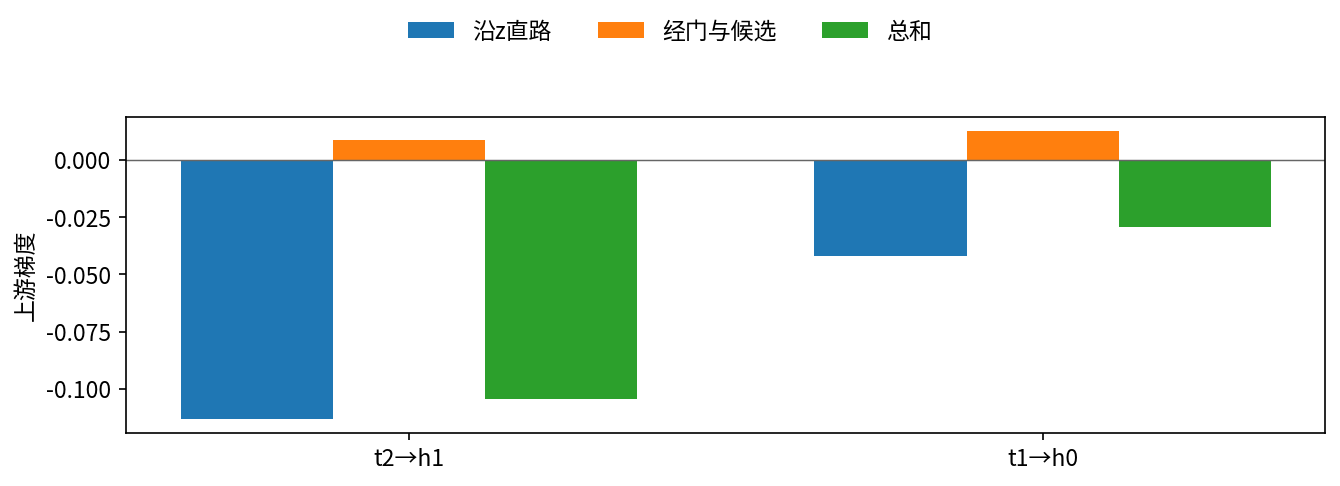

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 12 tests in 0.627s

OK


In [3]:
back=hand[0]['samples'][0]['backward'];fig,ax=plt.subplots(figsize=(9,3.3));x=np.arange(2)
for j,(key,label) in enumerate([('dh_prev_direct','沿z直路'),('dh_prev_via_gates','经门与候选'),('dh_prev_total','总和')]):ax.bar(x+(j-1)*.24,[b[key] for b in back],.24,label=label)
ax.axhline(0,color='#666',lw=.7);ax.set_xticks(x,['t2→h1','t1→h0']);ax.set_ylabel('上游梯度');fig.legend(*ax.get_legend_handles_labels(),loc='upper center',ncol=3,frameon=False);fig.tight_layout(rect=[0,0,1,.82]);show(fig)
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment);tests=unittest.TextTestRunner(verbosity=1,stream=sys.stdout).run(suite);require(tests.wasSuccessful(),'科学参照或契约测试失败')

## 3 边界和停止
源输入允许完整读取；decoder训练输入只含BOS及先前真实目标。自由生成不用金标长度停止。

In [4]:
source,sm,din,y,dm=batch([[4,5],[6],[]],pad_extra=2)
print('encoder=',source,'encoder mask=',sm.astype(int),'decoder=',din,'target=',y,'target mask=',dm.astype(int),sep='\n')
require(int(sm.sum())==9 and int(dm.sum())==6,'边界计数错误')
p=initialize('rnn',5191);p['outW'][:]=0;p['outb'][:]=-10;p['outb'][2]=10
print('恒EOS头：',greedy(p,'rnn',[[4,5],[]]))
p['outb'][2]=-10;p['outb'][0]=10
print('恒PAD头不自动过滤，到达上限：',greedy(p,'rnn',[[4,5]],max_steps=3))

encoder=
[[1 4 5 2 0 0]
 [1 6 2 0 0 0]
 [1 2 0 0 0 0]]
encoder mask=
[[1 1 1 1 0 0]
 [1 1 1 0 0 0]
 [1 1 0 0 0 0]]
decoder=
[[1 5 4 0 0]
 [1 6 0 0 0]
 [1 0 0 0 0]]
target=
[[5 4 2 0 0]
 [6 2 0 0 0]
 [2 0 0 0 0]]
target mask=
[[1 1 1 0 0]
 [1 1 0 0 0]
 [1 0 0 0 0]]
恒EOS头： [[2], [2]]
恒PAD头不自动过滤，到达上限： [[0, 0, 0]]


## 4 六模型完整重训与逐步核对
两架构×3种子×300步。验证集不选模型，不因GRU较差改变协议。数据与所有结果通过同一环境原字节比较；跨版本差异应先核环境，不自动改容差。

In [5]:
data=json.loads((root/'data/sequences.json').read_text())
with tempfile.TemporaryDirectory(prefix='dl051-replay-') as directory:
    out=Path(directory);fresh=run(out)
    for name in ['results.json','training_traces.json.gz','final_states.json.gz']:require((out/name).read_bytes()==(root/'outputs'/name).read_bytes(),name+'没有原字节复现，请先核环境')
    audit_result=audit(out);traces=json.loads(gzip.decompress((out/'training_traces.json.gz').read_bytes()))
print('六模型与1806状态重现；NumPy逐步结果：',audit_result)
print(json.dumps(fresh['summary'],indent=2))

六模型与1806状态重现；NumPy逐步结果： {'updates': 1800, 'states': 1806, 'max_update_abs': 4.440892098500626e-16, 'max_loss_abs': 8.881784197001252e-16, 'max_gradient_norm_abs': 8.881784197001252e-16}
{
  "rnn": {
    "test": {
      "teacher_forced_nll": 0.5174689700817452,
      "teacher_forced_token_accuracy": 0.8098434004474274,
      "teacher_forced_sequence_exact": 0.3177083333333333,
      "free_sequence_exact": 0.3177083333333333,
      "free_aligned_token_accuracy": 0.7695749440715884,
      "eos_rate": 1.0
    },
    "long_test": {
      "teacher_forced_nll": 2.720769140225903,
      "teacher_forced_token_accuracy": 0.469558599695586,
      "teacher_forced_sequence_exact": 0.0,
      "free_sequence_exact": 0.0,
      "free_aligned_token_accuracy": 0.378234398782344,
      "eos_rate": 0.9947916666666666
    }
  },
  "gru": {
    "test": {
      "teacher_forced_nll": 0.8160505194657297,
      "teacher_forced_token_accuracy": 0.6633109619686801,
      "teacher_forced_sequence_exact": 0.078125,

## 5 完整训练曲线
所有种子原曲线保留。两个架构同H、同更新数，参数和计算量仍不相同。

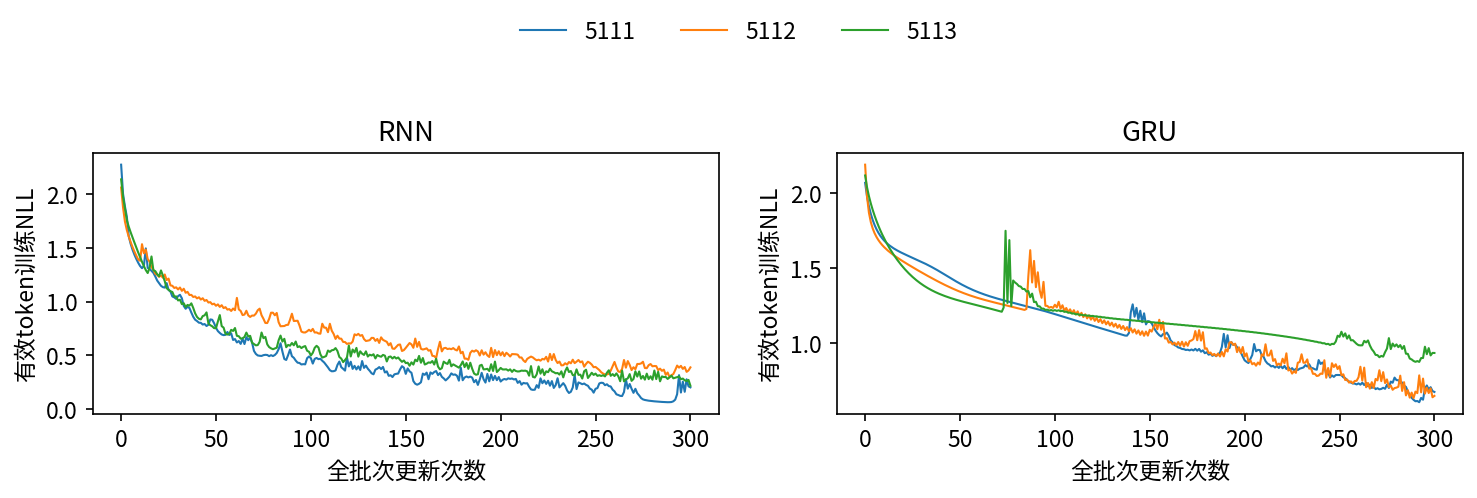

In [6]:
fig,axs=plt.subplots(1,2,figsize=(10,3.4))
for ax,kind in zip(axs,['rnn','gru']):
    for trace in traces:
        if trace['kind']==kind:ax.plot([s['step'] for s in trace['states']],[s['train_nll'] for s in trace['states']],label=str(trace['seed']),lw=1)
    ax.set(title=kind.upper(),xlabel='全批次更新次数',ylabel='有效token训练NLL')
fig.legend(*axs[0].get_legend_handles_labels(),loc='upper center',ncol=3,frameon=False);fig.tight_layout(rect=[0,0,1,.82]);show(fig)

## 6 实际自由输出
确定性greedy下teacher-forced全位置exact与free exact相等；两种token准确率不必相等。EOS率不等于任务成功率。

rnn 5111 TF token 0.8456375838926175 free token 0.8355704697986577 exact 0.453125
rnn 5112 TF token 0.7583892617449665 free token 0.6409395973154363 exact 0.125
rnn 5113 TF token 0.825503355704698 free token 0.8322147651006712 exact 0.375
gru 5111 TF token 0.7013422818791947 free token 0.5369127516778524 exact 0.046875
gru 5112 TF token 0.6879194630872483 free token 0.49328859060402686 exact 0.140625
gru 5113 TF token 0.6006711409395973 free token 0.48322147651006714 exact 0.046875
rnn 固定test编号 0 source [7, 4, 5, 6] gold [6, 5, 4, 7, 2] decoded [6, 5, 4, 7, 2]
rnn 固定test编号 1 source [6, 4, 6, 7] gold [7, 6, 4, 6, 2] decoded [7, 6, 5, 2]
rnn 固定test编号 2 source [7, 5, 5, 4] gold [4, 5, 5, 7, 2] decoded [4, 5, 5, 7, 2]
rnn 固定test编号 3 source [4, 6, 5, 7] gold [7, 5, 6, 4, 2] decoded [7, 5, 6, 4, 2]
rnn 固定test编号 4 source [7, 7, 7] gold [7, 7, 7, 2] decoded [7, 7, 7, 2]
gru 固定test编号 0 source [7, 4, 5, 6] gold [6, 5, 4, 7, 2] decoded [6, 5, 4, 6, 2]
gru 固定test编号 1 source [6, 4, 6, 7] gold [7, 6

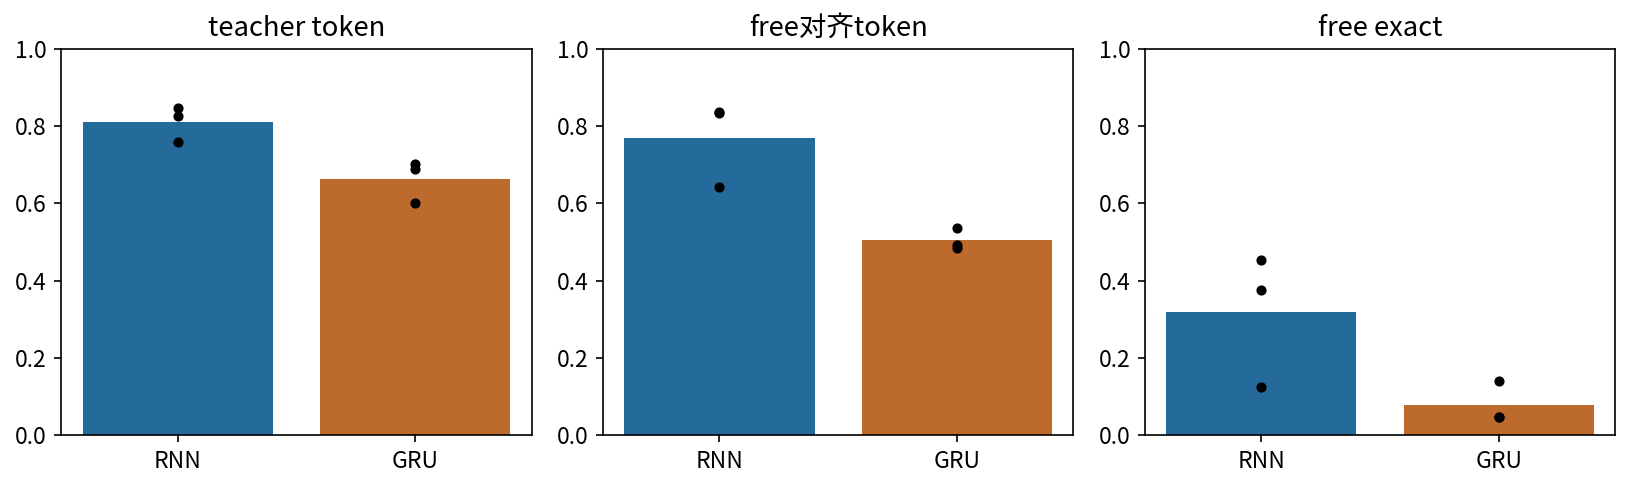

In [7]:
for record in fresh['runs']:
    for split in ['test','long_test']:require(record['metrics'][split]['teacher_forced_sequence_exact']==record['metrics'][split]['free_sequence_exact'],'确定性exact等价不符')
    m=record['metrics']['test'];print(record['kind'],record['seed'],'TF token',m['teacher_forced_token_accuracy'],'free token',m['free_aligned_token_accuracy'],'exact',m['free_sequence_exact'])
for kind in ['rnn','gru']:
    record=next(v for v in fresh['runs'] if v['kind']==kind and v['seed']==5111)
    for i in range(5):print(kind,'固定test编号',i,'source',data['test'][i],'gold',record['metrics']['test']['gold'][i],'decoded',record['metrics']['test']['decoded'][i])
fig,axs=plt.subplots(1,3,figsize=(11,3.4))
for ax,key,title in zip(axs,['teacher_forced_token_accuracy','free_aligned_token_accuracy','free_sequence_exact'],['teacher token','free对齐token','free exact']):
    ax.bar(['RNN','GRU'],[fresh['summary'][k]['test'][key] for k in ['rnn','gru']],color=['#246a9a','#bd6b2d']);ax.set(title=title,ylim=(0,1))
    for i,k in enumerate(['rnn','gru']):ax.scatter([i]*3,[v['metrics']['test'][key] for v in fresh['runs'] if v['kind']==k],color='black',s=15)
fig.tight_layout();show(fig)

## 7 长度外推与负面结果
长度5..6的exact全0，NLL和停止行为仍分别报告。没有因门控表现不佳追加训练。新实验必须先固定新协议，当前结果不能丢弃。

rnn 5111 长序列NLL 2.971037857998766 exact 0.0 EOS rate 1.0
rnn 5112 长序列NLL 2.4911560415638285 exact 0.0 EOS rate 1.0
rnn 5113 长序列NLL 2.700113521115116 exact 0.0 EOS rate 0.984375
gru 5111 长序列NLL 1.9777561564576926 exact 0.0 EOS rate 1.0
gru 5112 长序列NLL 1.6413344962216552 exact 0.0 EOS rate 1.0
gru 5113 长序列NLL 1.473464500205045 exact 0.0 EOS rate 1.0


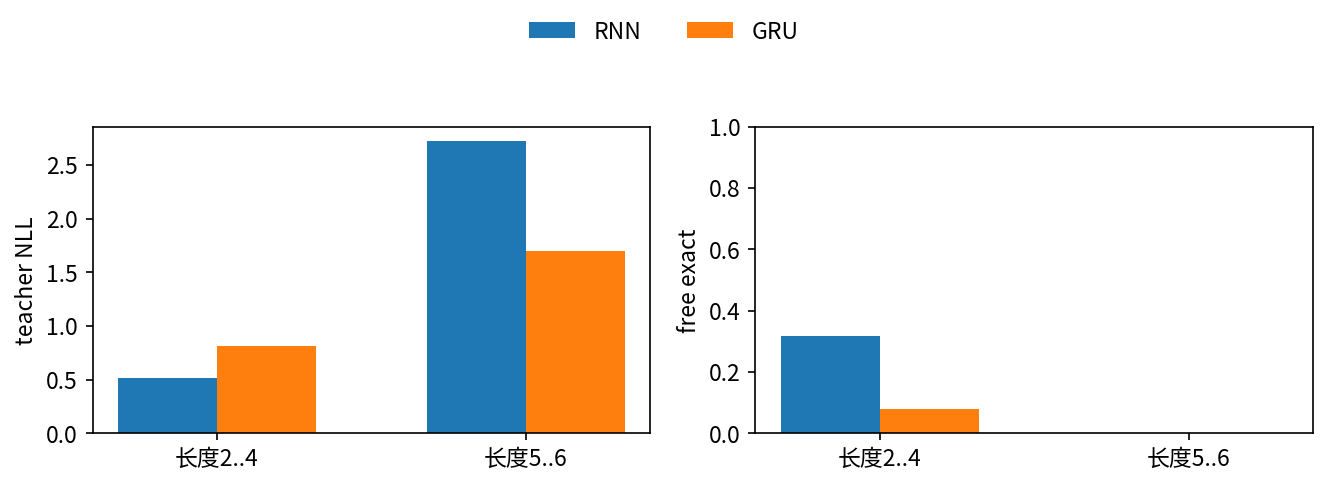

全部失败、原始输出与环境继续保留；toy任务不代表真实语言泛化。


In [8]:
for record in fresh['runs']:
    m=record['metrics']['long_test'];print(record['kind'],record['seed'],'长序列NLL',m['teacher_forced_nll'],'exact',m['free_sequence_exact'],'EOS rate',m['eos_rate']);require(m['free_sequence_exact']==0,'与固定长序列结果不同')
fig,axs=plt.subplots(1,2,figsize=(9,3.3));x=np.arange(2)
for i,k in enumerate(['rnn','gru']):
    axs[0].bar(x+(i-.5)*.32,[fresh['summary'][k][s]['teacher_forced_nll'] for s in ['test','long_test']],.32,label=k.upper())
    axs[1].bar(x+(i-.5)*.32,[fresh['summary'][k][s]['free_sequence_exact'] for s in ['test','long_test']],.32,label=k.upper())
for ax in axs:ax.set_xticks(x,['长度2..4','长度5..6'])
axs[0].set_ylabel('teacher NLL');axs[1].set_ylabel('free exact');axs[1].set_ylim(0,1);fig.legend(*axs[0].get_legend_handles_labels(),loc='upper center',ncol=2,frameon=False);fig.tight_layout(rect=[0,0,1,.82]);show(fig)
print('全部失败、原始输出与环境继续保留；toy任务不代表真实语言泛化。')